Verifying Dual T4 x2 GPU

In [1]:
import torch; 
print(torch.cuda.device_count())

2


In [2]:
import os

for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/thanakomsn/glove6b300dtxt/glove.6B.300d.txt
/kaggle/input/datasets/waseemalastal/customer-support-ticket-dataset/customer_support_tickets.csv


## Hybrid Semantic Retrieval & Intelligence System (HSRIS)
### NLP Pipeline: Label Encoding → One-Hot → TF-IDF → GloVe → Hybrid Search

**Dataset:** Customer Support Ticket Dataset (~8,470 records)  
**Platform:** Kaggle Dual T4 x2 GPU  
**Framework:** Base PyTorch + NumPy (no sklearn)

 ### Imports & Device Setup

In [3]:
# ── Imports ───────────────────────────────────────────────────────────────────
import re, os, math, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter

import torch
import torch.nn as nn
from torch.nn.parallel import DataParallel

# ── Device Setup ──────────────────────────────────────────────────────────────
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
n_gpus = torch.cuda.device_count()

print(f"Device  : {device}")
print(f"GPUs    : {n_gpus}")
print(f"PyTorch : {torch.__version__}")

for i in range(n_gpus):
    print(f"  GPU {i}: {torch.cuda.get_device_name(i)}")

Device  : cuda
GPUs    : 2
PyTorch : 2.10.0+cu128
  GPU 0: Tesla T4
  GPU 1: Tesla T4


## Section 1: Load & Explore Datase

In [4]:
# ── File Paths ────────────────────────────────────────────────────────────────
DATA_PATH  = "/kaggle/input/datasets/waseemalastal/customer-support-ticket-dataset/customer_support_tickets.csv"
GLOVE_PATH = "/kaggle/input/datasets/thanakomsn/glove6b300dtxt/glove.6B.300d.txt"

# ── Load Dataset ──────────────────────────────────────────────────────────────
df_raw = pd.read_csv(DATA_PATH)
print(f"Raw shape: {df_raw.shape}")
print(f"Columns: {df_raw.columns.tolist()}")

Raw shape: (8469, 17)
Columns: ['Ticket ID', 'Customer Name', 'Customer Email', 'Customer Age', 'Customer Gender', 'Product Purchased', 'Date of Purchase', 'Ticket Type', 'Ticket Subject', 'Ticket Description', 'Ticket Status', 'Resolution', 'Ticket Priority', 'Ticket Channel', 'First Response Time', 'Time to Resolution', 'Customer Satisfaction Rating']


## Section 2: Data Preprocessing

In [5]:
# ── Select Only Required Columns ─────────────────────────────────────────────
REQUIRED_COLS = [
    "Ticket Description",
    "Ticket Subject", 
    "Ticket Priority",
    "Ticket Type",
    "Ticket Channel"
]

df = df_raw[REQUIRED_COLS].dropna().reset_index(drop=True)

print(f"Shape after cleaning : {df.shape}")
print(f"\nTicket Priority values  : {df['Ticket Priority'].unique()}")
print(f"Ticket Channel values   : {df['Ticket Channel'].unique()}")
print(f"Ticket Type values      : {df['Ticket Type'].unique()}")
print(f"\nSample description:\n{df['Ticket Description'].iloc[0]}")

Shape after cleaning : (8469, 5)

Ticket Priority values  : ['Critical' 'Low' 'High' 'Medium']
Ticket Channel values   : ['Social media' 'Chat' 'Email' 'Phone']
Ticket Type values      : ['Technical issue' 'Billing inquiry' 'Cancellation request'
 'Product inquiry' 'Refund request']

Sample description:
I'm having an issue with the {product_purchased}. Please assist.

Your billing zip code is: 71701.

We appreciate that you have requested a website address.

Please double check your email address. I've tried troubleshooting steps mentioned in the user manual, but the issue persists.


## Section 3: Part 1 — Categorical Encoders
### Part 1A: Label Encoding (Ticket Priority)

In [6]:
# ── Label Encoding from scratch — no sklearn ──────────────────────────────────
# Ordinal mapping: Low=0, Medium=1, High=2, Critical=3
# Unseen categories → -1 (safe default for inference)

PRIORITY_MAP = {
    "Low"      : 0,
    "Medium"   : 1,
    "High"     : 2,
    "Critical" : 3
}

def label_encode_priority(series, mapping=PRIORITY_MAP):
    """
    Maps Ticket Priority strings to ordinal integers.
    Built from scratch using dict lookup — no sklearn LabelEncoder.
    Unseen category → -1
    """
    encoded = [mapping.get(str(v).strip(), -1) for v in series]
    return torch.tensor(encoded, dtype=torch.long)

# ── Apply & Verify ────────────────────────────────────────────────────────────
priority_encoded = label_encode_priority(df["Ticket Priority"])

print("Label Encoding — Ticket Priority")
print("="*40)
print(f"Mapping used     : {PRIORITY_MAP}")
print(f"Output shape     : {priority_encoded.shape}")
print(f"Unique values    : {priority_encoded.unique()}")
print(f"Sample (first 10): {priority_encoded[:10]}")

# Verify alignment
print(f"\nAlignment check:")
for i in range(5):
    print(f"  '{df['Ticket Priority'].iloc[i]}' → {priority_encoded[i].item()}")

# Inference guard — unseen category test
test_unseen = label_encode_priority(["Unknown", "VeryHigh"])
print(f"\nUnseen category test: {test_unseen}")
print("Unseen → -1 ✓" if (test_unseen == -1).all() else "ERROR: unseen not handled!")

Label Encoding — Ticket Priority
Mapping used     : {'Low': 0, 'Medium': 1, 'High': 2, 'Critical': 3}
Output shape     : torch.Size([8469])
Unique values    : tensor([0, 1, 2, 3])
Sample (first 10): tensor([3, 3, 0, 0, 0, 0, 3, 3, 0, 3])

Alignment check:
  'Critical' → 3
  'Critical' → 3
  'Low' → 0
  'Low' → 0
  'Low' → 0

Unseen category test: tensor([-1, -1])
Unseen → -1 ✓


### Part 1B: One-Hot Encoding (Ticket Channel)

In [7]:
# ── One-Hot Encoding from scratch — no sklearn ────────────────────────────────

def build_channel_vocab(series):
    """
    Builds channel → index mapping from training data.
    Sorted for consistency across runs.
    """
    unique = sorted(set(str(v).strip() for v in series if pd.notna(v)))
    return {ch: idx for idx, ch in enumerate(unique)}

def one_hot_encode_channel(series, mapping):
    """
    Converts Ticket Channel strings to binary one-hot vectors.
    Output shape: (N, num_classes)
    Unseen categories → zero vector (safe inference handling)
    No sklearn — pure PyTorch tensor operations.
    """
    n_classes = len(mapping)
    indices   = [mapping.get(str(v).strip(), -1) for v in series]
    ohe       = torch.zeros(len(indices), n_classes, dtype=torch.float32)
    for i, idx in enumerate(indices):
        if idx >= 0:
            ohe[i, idx] = 1.0
    return ohe

# ── Apply & Verify ────────────────────────────────────────────────────────────
CHANNEL_MAP     = build_channel_vocab(df["Ticket Channel"])
channel_encoded = one_hot_encode_channel(df["Ticket Channel"], CHANNEL_MAP)

print("One-Hot Encoding — Ticket Channel")
print("="*40)
print(f"Channel vocabulary : {CHANNEL_MAP}")
print(f"Output shape       : {channel_encoded.shape}")
print(f"\nSample rows (first 5):")
for i in range(5):
    ch  = df["Ticket Channel"].iloc[i]
    vec = channel_encoded[i].tolist()
    print(f"  '{ch}' → {vec}")

# Inference guard — unseen category test
unseen_vec = one_hot_encode_channel(["UnknownChannel"], CHANNEL_MAP)
print(f"\nUnseen category → zero vector: {unseen_vec}")
print("Unseen → zero vector ✓" if unseen_vec.sum() == 0 else "ERROR!")

# Verify one-hot property — each row sums to exactly 1
row_sums = channel_encoded.sum(dim=1)
all_ones = (row_sums == 1.0).all()
print(f"All rows sum to 1  : {all_ones.item()} ✓")

One-Hot Encoding — Ticket Channel
Channel vocabulary : {'Chat': 0, 'Email': 1, 'Phone': 2, 'Social media': 3}
Output shape       : torch.Size([8469, 4])

Sample rows (first 5):
  'Social media' → [0.0, 0.0, 0.0, 1.0]
  'Chat' → [1.0, 0.0, 0.0, 0.0]
  'Social media' → [0.0, 0.0, 0.0, 1.0]
  'Social media' → [0.0, 0.0, 0.0, 1.0]
  'Email' → [0.0, 1.0, 0.0, 0.0]

Unseen category → zero vector: tensor([[0., 0., 0., 0.]])
Unseen → zero vector ✓
All rows sum to 1  : True ✓


## Section 4: Part 2 — Sparse Representation (TF-IDF)
### Part 2A: Custom Tokenizer & N-gram Generator

In [8]:
# ── Custom Tokenizer — regex based, no nltk/sklearn ──────────────────────────
# Cleaned STOPWORDS — safe for support tickets
STOPWORDS = {
    "a","an","the","is","it","in","on","at","to","for","of","and",
    "or","but","with","this","that","was","are","be","been","have",
    "has","had","i","we","my","your","you","he","she","they","its",
    "do","did","so","if","as","by","from","about","just",
    "also","more","than",
    "me","us","him","her","them","our","their","what","which","who",
    "how","when","where","there","here","am","being",
    "all","any","some","one","two","into"
}

def tokenize(text: str) -> list:
    """
    Step 1: lowercase
    Step 2: remove punctuation via regex (keep alphanumeric + spaces)
    Step 3: split on whitespace
    Step 4: remove stopwords and empty tokens
    No sklearn, no nltk — pure regex + Python.
    """
    text   = str(text).lower()
    text   = re.sub(r"[^a-z0-9\s]", " ", text)
    tokens = text.split()
    return [t for t in tokens if t and t not in STOPWORDS]

def get_ngrams(tokens: list, n: int) -> list:
    """
    Sliding window n-gram generator.
    get_ngrams(['not','working','billing'], 2)
    → ['not_working', 'working_billing']
    """
    return [
        "_".join(tokens[i:i+n])
        for i in range(len(tokens) - n + 1)
    ]

def tokenize_with_ngrams(text: str) -> list:
    """
    Returns unigrams + bigrams + trigrams combined.
    Captures context like 'not_working' vs 'is_working'.
    Used for TF-IDF document representation.
    """
    tokens   = tokenize(text)
    bigrams  = get_ngrams(tokens, 2)
    trigrams = get_ngrams(tokens, 3)
    return tokens + bigrams + trigrams

# ── Test & Verify ─────────────────────────────────────────────────────────────
test_text = "My laptop screen is not working after the update!"

print("Tokenizer Test")
print("="*40)
print(f"Input     : {test_text}")
print(f"Tokens    : {tokenize(test_text)}")
print(f"Bigrams   : {get_ngrams(tokenize(test_text), 2)}")
print(f"Trigrams  : {get_ngrams(tokenize(test_text), 3)}")
print(f"Combined  : {tokenize_with_ngrams(test_text)}")
print(f"\nTotal features from this sentence: {len(tokenize_with_ngrams(test_text))}")

Tokenizer Test
Input     : My laptop screen is not working after the update!
Tokens    : ['laptop', 'screen', 'not', 'working', 'after', 'update']
Bigrams   : ['laptop_screen', 'screen_not', 'not_working', 'working_after', 'after_update']
Trigrams  : ['laptop_screen_not', 'screen_not_working', 'not_working_after', 'working_after_update']
Combined  : ['laptop', 'screen', 'not', 'working', 'after', 'update', 'laptop_screen', 'screen_not', 'not_working', 'working_after', 'after_update', 'laptop_screen_not', 'screen_not_working', 'not_working_after', 'working_after_update']

Total features from this sentence: 15


### Part 2B: Vocabulary Building & Bag of Words (Count Vectorizer)

In [9]:
# ── Build Vocabulary (top 5,000 tokens) ──────────────────────────────────────
# No sklearn CountVectorizer — built from scratch using Counter

VOCAB_SIZE = 5000
corpus     = df["Ticket Description"].astype(str).tolist()

print("Building vocabulary...")
all_tokens = []
for doc in corpus:
    all_tokens.extend(tokenize_with_ngrams(doc))

vocab_counter = Counter(all_tokens)
top_tokens    = [tok for tok, _ in vocab_counter.most_common(VOCAB_SIZE)]
vocab         = {tok: idx for idx, tok in enumerate(top_tokens)}

print(f"Vocabulary built!")
print("="*40)
print(f"Total unique tokens found : {len(vocab_counter)}")
print(f"Vocabulary size (top)     : {len(vocab)}")
print(f"\nTop 20 most frequent tokens:")
for tok, cnt in vocab_counter.most_common(20):
    print(f"  '{tok}' → {cnt}")

Building vocabulary...
Vocabulary built!
Total unique tokens found : 137710
Vocabulary size (top)     : 5000

Top 20 most frequent tokens:
  'product' → 16998
  'purchased' → 14454
  'product_purchased' → 14240
  'issue' → 11532
  'm' → 10322
  'please' → 8815
  'having' → 6430
  'm_having' → 6344
  'issue_product' → 6331
  'assist' → 6258
  'issue_product_purchased' → 6252
  'please_assist' → 6247
  'having_issue' → 6175
  'm_having_issue' → 6150
  've' → 6120
  'purchased_please' → 6120
  'product_purchased_please' → 6117
  'having_issue_product' → 6114
  'purchased_please_assist' → 6107
  'can' → 2449


### Part 2C: TF-IDF Implementation (Sparse Tensor)

In [10]:
# ── Step 1: Tokenise entire corpus ───────────────────────────────────────────
print("Tokenising corpus...")
tokenised_corpus = [tokenize_with_ngrams(doc) for doc in corpus]
print(f"Tokenised {len(tokenised_corpus)} documents")

# ── Step 2: Compute IDF scores ────────────────────────────────────────────────
# Smooth IDF formula: log((N+1) / (df+1)) + 1
# Prevents division by zero and reduces weight of very common terms
print("\nComputing IDF scores...")
N          = len(tokenised_corpus)
df_counts  = Counter()

for tokens in tokenised_corpus:
    for tok in set(tokens):          # unique per doc for DF
        if tok in vocab:
            df_counts[tok] += 1

idf = torch.zeros(VOCAB_SIZE, dtype=torch.float32)
for tok, idx in vocab.items():
    idf[idx] = math.log((N + 1) / (df_counts.get(tok, 0) + 1)) + 1.0

print(f"IDF computed!")
print(f"  Min IDF : {idf.min().item():.4f}")
print(f"  Max IDF : {idf.max().item():.4f}")
print(f"  Mean IDF: {idf.mean().item():.4f}")

# ── Step 3: Build sparse TF-IDF matrix ───────────────────────────────────────
# Using torch.sparse — never dense (would crash RAM)
print("\nBuilding sparse TF-IDF matrix...")
rows, cols, vals = [], [], []

for doc_id, tokens in enumerate(tokenised_corpus):
    tf     = Counter(tokens)
    max_tf = max(tf.values(), default=1)
    for tok, count in tf.items():
        if tok in vocab:
            col    = vocab[tok]
            tf_val = count / max_tf        # normalised TF
            tfidf  = tf_val * idf[col].item()
            rows.append(doc_id)
            cols.append(col)
            vals.append(tfidf)

indices      = torch.tensor([rows, cols], dtype=torch.long)
values       = torch.tensor(vals,        dtype=torch.float32)
tfidf_sparse = torch.sparse_coo_tensor(
    indices, values, (N, VOCAB_SIZE)
).coalesce()

print(f"Sparse TF-IDF matrix built!")
print("="*40)
print(f"Shape          : {tfidf_sparse.shape}")
print(f"Non-zero values: {tfidf_sparse._nnz()}")
print(f"Sparsity       : {100 * (1 - tfidf_sparse._nnz() / (N * VOCAB_SIZE)):.2f}%")

# ── Step 4: Build normalised dense version for cosine similarity ──────────────
print("\nBuilding normalised TF-IDF matrix for search...")
tfidf_dense = tfidf_sparse.to_dense()
tfidf_norm  = tfidf_dense / (tfidf_dense.norm(dim=1, keepdim=True) + 1e-9)
tfidf_norm  = tfidf_norm.to(device)
print(f"Normalised TF-IDF matrix shape: {tfidf_norm.shape}")
print(f"Device: {tfidf_norm.device}")

# ── Step 5: Pre-compute per-doc TF-IDF dicts for GloVe weighted pooling ───────
print("\nBuilding per-document TF-IDF dicts...")
tfidf_dicts = []
for tokens in tokenised_corpus:
    tf     = Counter(tokens)
    max_tf = max(tf.values(), default=1)
    d = {
        tok: (cnt / max_tf) * idf[vocab[tok]].item()
        for tok, cnt in tf.items()
        if tok in vocab
    }
    tfidf_dicts.append(d)
print(f"TF-IDF dicts built for {len(tfidf_dicts)} documents")

Tokenising corpus...
Tokenised 8469 documents

Computing IDF scores...
IDF computed!
  Min IDF : 1.0000
  Max IDF : 9.3511
  Mean IDF: 6.8339

Building sparse TF-IDF matrix...
Sparse TF-IDF matrix built!
Shape          : torch.Size([8469, 5000])
Non-zero values: 544349
Sparsity       : 98.71%

Building normalised TF-IDF matrix for search...
Normalised TF-IDF matrix shape: torch.Size([8469, 5000])
Device: cuda:0

Building per-document TF-IDF dicts...
TF-IDF dicts built for 8469 documents


## Section 5: Part 3 — Dense Semantic Layer (GloVe Embeddings)
### Part 3A: Load GloVe 300d into torch.nn.Embedding

In [11]:
# ── Load GloVe 300-d → torch.nn.Embedding ────────────────────────────────────
# OOV (out-of-vocabulary) tokens → last index = zero vector
# Embedding layer is frozen (freeze=True) — we don't train it

GLOVE_DIM = 300

print("Loading GloVe 300d vectors...")
print("(This takes ~2 minutes — please wait)")

glove_word2idx = {}
glove_vectors  = []

with open(GLOVE_PATH, encoding="utf-8") as f:
    for line in f:
        parts = line.rstrip().split(" ")
        word  = parts[0]
        vec   = list(map(float, parts[1:]))
        if len(vec) == GLOVE_DIM:
            glove_word2idx[word] = len(glove_vectors)
            glove_vectors.append(vec)

# ── Add <UNK> token as last entry — zero vector ───────────────────────────────
UNK_IDX = len(glove_vectors)
glove_vectors.append([0.0] * GLOVE_DIM)

# ── Load into frozen Embedding layer ─────────────────────────────────────────
weight_matrix   = torch.tensor(glove_vectors, dtype=torch.float32)
embedding_layer = nn.Embedding.from_pretrained(
    weight_matrix,
    freeze=True,
    padding_idx=UNK_IDX
)
embedding_layer = embedding_layer.to(device)

print(f"\nGloVe loaded successfully!")
print("="*40)
print(f"GloVe vocabulary size : {len(glove_word2idx)}")
print(f"Embedding matrix shape: {weight_matrix.shape}")
print(f"UNK token index       : {UNK_IDX}")
print(f"Embedding device      : {next(embedding_layer.parameters()).device}")

# ── OOV test ──────────────────────────────────────────────────────────────────
test_words = ["billing", "laptop", "xyzabc123unknown"]
print(f"\nOOV handling test:")
for w in test_words:
    idx = glove_word2idx.get(w, UNK_IDX)
    status = "IN vocab" if idx != UNK_IDX else "OOV → zero vector"
    print(f"  '{w}' → index {idx} ({status})")

Loading GloVe 300d vectors...
(This takes ~2 minutes — please wait)

GloVe loaded successfully!
GloVe vocabulary size : 400000
Embedding matrix shape: torch.Size([400001, 300])
UNK token index       : 400000
Embedding device      : cuda:0

OOV handling test:
  'billing' → index 13703 (IN vocab)
  'laptop' → index 10819 (IN vocab)
  'xyzabc123unknown' → index 400000 (OOV → zero vector)


### Part 3B: TF-IDF Weighted Mean Pooling (Sentence Vectors)

In [12]:
# ── TF-IDF Weighted Mean Pooling ──────────────────────────────────────────────
# Why weighted? Simple average drowns rare keywords like "billing" or "kernel"
# in common words like "please" or "having".
# TF-IDF weight ensures rare technical words contribute more to the vector.

def text_to_glove_vector(text, tfidf_row=None):
    """
    Converts text → 300-d vector using TF-IDF weighted mean pooling.
    
    Args:
        text      : raw ticket description string
        tfidf_row : {token: tfidf_score} dict for this doc
                    If None → uniform weights (for query encoding)
    
    OOV tokens → zero vector, weight=0 (excluded from average)
    Fallback   → plain mean if all tokens are OOV
    """
    tokens = tokenize(text)

    if not tokens:
        return torch.zeros(GLOVE_DIM, device=device)

    indices, weights = [], []
    for tok in tokens:
        idx = glove_word2idx.get(tok, UNK_IDX)
        if idx == UNK_IDX:
            w = 0.0              # OOV → excluded
        else:
            w = tfidf_row.get(tok, 0.0) if tfidf_row else 1.0
        indices.append(idx)
        weights.append(w)

    idx_t = torch.tensor(indices, dtype=torch.long,    device=device)
    w_t   = torch.tensor(weights, dtype=torch.float32, device=device)
    vecs  = embedding_layer(idx_t)                     # (T, 300)

    w_sum = w_t.sum()
    if w_sum == 0:
        return vecs.mean(0)                            # fallback plain mean
    return (vecs * w_t.unsqueeze(1)).sum(0) / w_sum   # weighted mean


# ── Build GloVe corpus matrix ─────────────────────────────────────────────────
print("Building GloVe corpus matrix...")
print("(Encoding 8,469 documents — takes ~1 minute)")

glove_matrix = torch.stack([
    text_to_glove_vector(doc, tfidf_dicts[i])
    for i, doc in enumerate(corpus)
])

# ── L2 normalise for cosine similarity ───────────────────────────────────────
glove_norm = glove_matrix / (glove_matrix.norm(dim=1, keepdim=True) + 1e-9)
glove_norm = glove_norm.to(device)

print(f"\nGloVe corpus matrix built!")
print("="*40)
print(f"Matrix shape  : {glove_norm.shape}")
print(f"Device        : {glove_norm.device}")
print(f"Sample vector norm (should be ~1.0): {glove_norm[0].norm().item():.4f}")

# ── Weighted vs plain mean comparison ────────────────────────────────────────
print(f"\nWeighted pooling demo:")
sample_text = corpus[0]
v_weighted  = text_to_glove_vector(sample_text, tfidf_dicts[0])
v_plain     = text_to_glove_vector(sample_text, None)
similarity  = torch.cosine_similarity(
    v_weighted.unsqueeze(0),
    v_plain.unsqueeze(0)
).item()
print(f"  Cosine sim (weighted vs plain): {similarity:.4f}")
print(f"  (< 1.0 confirms they differ — weighted pooling is working)")

Building GloVe corpus matrix...
(Encoding 8,469 documents — takes ~1 minute)

GloVe corpus matrix built!
Matrix shape  : torch.Size([8469, 300])
Device        : cuda:0
Sample vector norm (should be ~1.0): 1.0000

Weighted pooling demo:
  Cosine sim (weighted vs plain): 0.9600
  (< 1.0 confirms they differ — weighted pooling is working)


## Section 6: Task 2 — Hybrid Search Logic

In [13]:
# ── Query TF-IDF encoder ──────────────────────────────────────────────────────
def tfidf_query_vector(text):
    """
    Encodes a query string as a dense TF-IDF vector.
    Shape: (VOCAB_SIZE,)
    Uses same vocab and IDF scores as corpus.
    """
    tokens = tokenize_with_ngrams(text)
    tf     = Counter(tokens)
    max_tf = max(tf.values(), default=1)
    vec    = torch.zeros(VOCAB_SIZE, dtype=torch.float32)
    for tok, count in tf.items():
        if tok in vocab:
            vec[vocab[tok]] = (count / max_tf) * idf[vocab[tok]].item()
    return vec


# ── Hybrid Search Function ────────────────────────────────────────────────────
def hybrid_search(query, alpha=0.5, top_k=5):
    """
    Returns top-k tickets ranked by hybrid score:
        score = alpha * cosine(TF-IDF) + (1 - alpha) * cosine(GloVe)

    alpha = 1.0 → pure keyword search  (TF-IDF only)
    alpha = 0.0 → pure semantic search (GloVe only)
    alpha = 0.5 → balanced blend

    Args:
        query  : raw query string
        alpha  : blending weight (0.0 to 1.0)
        top_k  : number of results to return
    """
    # ── TF-IDF cosine similarity ──────────────────────────────────────────────
    q_tfidf = tfidf_query_vector(query).to(device)
    q_tfidf = q_tfidf / (q_tfidf.norm() + 1e-9)
    sim_tfidf = tfidf_norm @ q_tfidf                   # (N,)

    # ── GloVe cosine similarity ───────────────────────────────────────────────
    q_glove = text_to_glove_vector(query, None)
    q_glove = q_glove / (q_glove.norm() + 1e-9)
    sim_glove = glove_norm @ q_glove                   # (N,)

    # ── Hybrid score ──────────────────────────────────────────────────────────
    score = alpha * sim_tfidf + (1 - alpha) * sim_glove
    topk  = score.topk(top_k)

    results             = df.iloc[topk.indices.cpu().tolist()].copy()
    results["score"]    = topk.values.cpu().detach().numpy()
    results["sim_tfidf"] = sim_tfidf[topk.indices].cpu().detach().numpy()
    results["sim_glove"] = sim_glove[topk.indices].cpu().detach().numpy()
    return results[[
        "Ticket Description","Ticket Type",
        "Ticket Priority","Ticket Channel",
        "score","sim_tfidf","sim_glove"
    ]]


# ── Test hybrid search ────────────────────────────────────────────────────────
print("Hybrid Search Test")
print("="*40)
test_query = "my payment failed and I was charged twice"
print(f"Query : '{test_query}'")
print(f"Alpha : 0.5 (balanced)\n")

results = hybrid_search(test_query, alpha=0.5, top_k=5)
for i, (_, row) in enumerate(results.iterrows(), 1):
    print(f"Result {i}:")
    print(f"  Type     : {row['Ticket Type']}")
    print(f"  Priority : {row['Ticket Priority']}")
    print(f"  Score    : {row['score']:.4f} "
          f"(tfidf={row['sim_tfidf']:.4f}, glove={row['sim_glove']:.4f})")
    print(f"  Desc     : {str(row['Ticket Description'])[:100]}...")
    print()

Hybrid Search Test
Query : 'my payment failed and I was charged twice'
Alpha : 0.5 (balanced)

Result 1:
  Type     : Technical issue
  Priority : Medium
  Score    : 0.5046 (tfidf=0.2338, glove=0.7755)
  Desc     : I'm having an issue with the {product_purchased}. Please assist. Thank you."

The user had no idea t...

Result 2:
  Type     : Product inquiry
  Priority : Low
  Score    : 0.4894 (tfidf=0.2147, glove=0.7641)
  Desc     : I'm having an issue with the {product_purchased}. Please assist.

We will NOT make any money without...

Result 3:
  Type     : Product inquiry
  Priority : Medium
  Score    : 0.4801 (tfidf=0.1928, glove=0.7674)
  Desc     : I'm having an issue with the {product_purchased}. Please assist.

The product will be charged for ea...

Result 4:
  Type     : Billing inquiry
  Priority : Medium
  Score    : 0.4798 (tfidf=0.2525, glove=0.7070)
  Desc     : I'm having an issue with the {product_purchased}. Please assist.

Note: The product "Purchasing" is ...

Resu

## Section 7: Task 3 — Dual GPU Performance Optimization

In [14]:
# ── Similarity Model for DataParallel ─────────────────────────────────────────
class SimilarityModel(nn.Module):
    """
    Wraps GloVe corpus matrix for DataParallel batch cosine similarity.
    Forward: queries (B, 300) → similarities (B, N_docs)
    Splitting query batch across both T4 GPUs.
    """
    def __init__(self, corpus_matrix):
        super().__init__()
        self.register_buffer("corpus", corpus_matrix)

    def forward(self, queries):
        q_norm = queries / (queries.norm(dim=1, keepdim=True) + 1e-9)
        return q_norm @ self.corpus.T                  # (B, N_docs)


# ── Build model + wrap in DataParallel ───────────────────────────────────────
sim_model = SimilarityModel(glove_norm)
if torch.cuda.device_count() > 1:
    sim_model = DataParallel(sim_model)
    print(f"DataParallel enabled across {torch.cuda.device_count()} GPUs")
sim_model = sim_model.to(device)

# ── Batch of 100 test queries ─────────────────────────────────────────────────
print("\nEncoding 100 test queries...")
test_queries_text = df["Ticket Description"].sample(100, random_state=42).tolist()
test_batch = torch.stack([
    text_to_glove_vector(q) for q in test_queries_text
]).to(device)
print(f"Test batch shape: {test_batch.shape}")

# ── Time the batch on dual GPU ────────────────────────────────────────────────
torch.cuda.synchronize()
t0 = time.time()
with torch.no_grad():
    batch_sims = sim_model(test_batch)                 # (100, N_docs)
torch.cuda.synchronize()
elapsed = time.time() - t0

print(f"\nDual GPU Batch Results")
print("="*40)
print(f"Queries processed : 100")
print(f"Corpus size       : {glove_norm.shape[0]}")
print(f"Output shape      : {batch_sims.shape}")
print(f"Time taken        : {elapsed:.4f} seconds")
print(f"Queries/second    : {100/elapsed:.1f}")

# ── Verify output ─────────────────────────────────────────────────────────────
top1_indices = batch_sims.argmax(dim=1)
print(f"\nTop-1 match for first 3 queries:")
for i in range(3):
    idx = top1_indices[i].item()
    print(f"  Query {i+1} → best match index {idx} "
          f"(score={batch_sims[i,idx].item():.4f})")

DataParallel enabled across 2 GPUs

Encoding 100 test queries...
Test batch shape: torch.Size([100, 300])

Dual GPU Batch Results
Queries processed : 100
Corpus size       : 8469
Output shape      : torch.Size([100, 8469])
Time taken        : 0.7973 seconds
Queries/second    : 125.4

Top-1 match for first 3 queries:
  Query 1 → best match index 4830 (score=0.9745)
  Query 2 → best match index 7075 (score=0.9664)
  Query 3 → best match index 4715 (score=0.9865)


## Section 8: Training Logs — Execution Time vs Batch Size

Benchmarking dual GPU across batch sizes...
  Batch   10 → 0.0019s  (5339.0 queries/sec)
  Batch   25 → 0.0017s  (14545.4 queries/sec)
  Batch   50 → 0.0019s  (26821.2 queries/sec)
  Batch  100 → 0.0018s  (56764.2 queries/sec)
  Batch  200 → 0.0021s  (93487.2 queries/sec)
  Batch  500 → 0.0030s  (168094.9 queries/sec)
  Batch 1000 → 0.0043s  (233068.7 queries/sec)


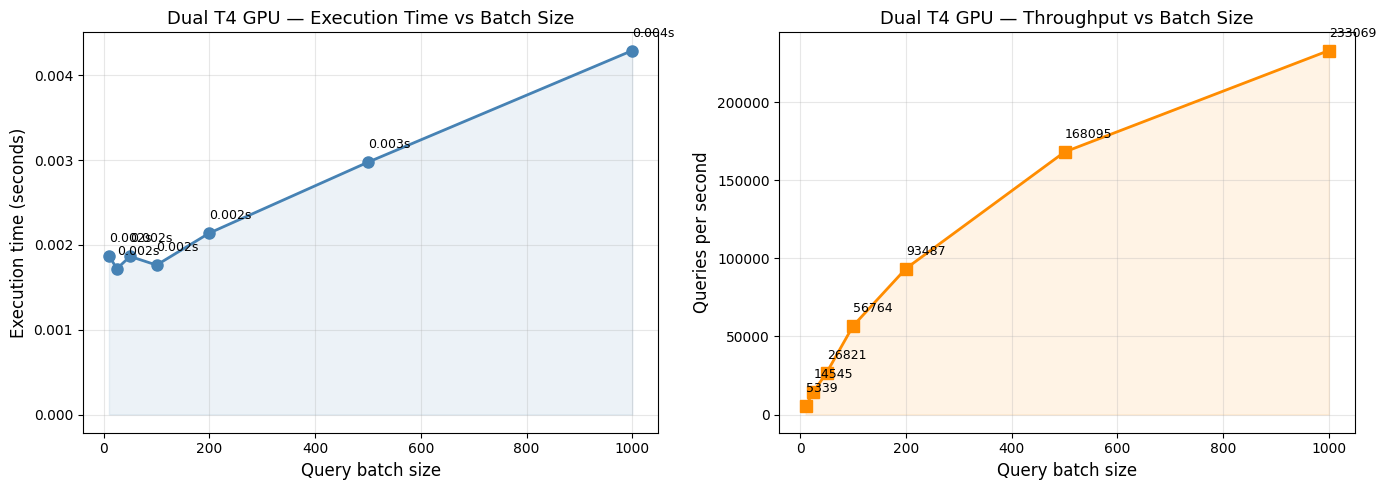


Plot saved as execution_time_plot.png


In [15]:
# ── Execution time vs batch size on dual GPU ──────────────────────────────────
batch_sizes = [10, 25, 50, 100, 200, 500, 1000]
times       = []
qps_list    = []

print("Benchmarking dual GPU across batch sizes...")
print("="*40)

for bs in batch_sizes:
    # Build batch by sampling from corpus
    sample_texts = df["Ticket Description"].sample(bs, random_state=0).tolist()
    batch = torch.stack([
        text_to_glove_vector(q) for q in sample_texts
    ]).to(device)

    # Warmup run
    with torch.no_grad():
        _ = sim_model(batch)
    torch.cuda.synchronize()

    # Timed run
    torch.cuda.synchronize()
    t0 = time.time()
    with torch.no_grad():
        _ = sim_model(batch)
    torch.cuda.synchronize()
    elapsed = time.time() - t0

    times.append(elapsed)
    qps_list.append(bs / elapsed)
    print(f"  Batch {bs:>4} → {elapsed:.4f}s  ({bs/elapsed:.1f} queries/sec)")

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Execution time vs batch size
ax1.plot(batch_sizes, times, marker="o", color="steelblue",
         linewidth=2, markersize=8)
ax1.fill_between(batch_sizes, times, alpha=0.1, color="steelblue")
ax1.set_xlabel("Query batch size", fontsize=12)
ax1.set_ylabel("Execution time (seconds)", fontsize=12)
ax1.set_title("Dual T4 GPU — Execution Time vs Batch Size", fontsize=13)
ax1.grid(True, alpha=0.3)
for x, y in zip(batch_sizes, times):
    ax1.annotate(f"{y:.3f}s", (x, y),
                 textcoords="offset points", xytext=(0, 10), fontsize=9)

# Plot 2: Queries per second vs batch size
ax2.plot(batch_sizes, qps_list, marker="s", color="darkorange",
         linewidth=2, markersize=8)
ax2.fill_between(batch_sizes, qps_list, alpha=0.1, color="darkorange")
ax2.set_xlabel("Query batch size", fontsize=12)
ax2.set_ylabel("Queries per second", fontsize=12)
ax2.set_title("Dual T4 GPU — Throughput vs Batch Size", fontsize=13)
ax2.grid(True, alpha=0.3)
for x, y in zip(batch_sizes, qps_list):
    ax2.annotate(f"{y:.0f}", (x, y),
                 textcoords="offset points", xytext=(0, 10), fontsize=9)

plt.tight_layout()
plt.savefig("execution_time_plot.png", dpi=150, bbox_inches="tight")
plt.show()
print("\nPlot saved as execution_time_plot.png")

## Section 9: Quantitative Evaluation — Precision@5

Computing Precision@5 over 200 queries...
  Alpha=0.0 → Precision@5 = 0.2110
  Alpha=0.3 → Precision@5 = 0.2050
  Alpha=0.5 → Precision@5 = 0.2040
  Alpha=0.7 → Precision@5 = 0.2060
  Alpha=1.0 → Precision@5 = 0.2000

Best alpha : 0.0
Best P@5   : 0.2110


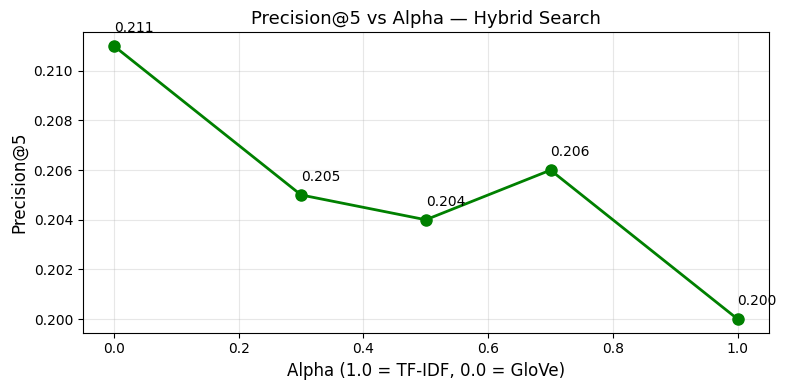

Plot saved as precision_at_5.png


In [16]:
# ── Precision@5 ───────────────────────────────────────────────────────────────
# For each query ticket, retrieve top 5 results and check how many
# share the same Ticket Type as the query. That's Precision@5.

def precision_at_k(query_idx, alpha=0.5, k=5):
    """
    Uses ticket at query_idx as the query.
    Returns fraction of top-k results matching its Ticket Type.
    Excludes the query itself from results.
    """
    query_text = corpus[query_idx]
    true_type  = df["Ticket Type"].iloc[query_idx]

    # Get top k+1 to exclude self
    results = hybrid_search(query_text, alpha=alpha, top_k=k+1)

    # Remove the query itself if it appears
    results = results[results.index != query_idx].head(k)
    hits    = (results["Ticket Type"] == true_type).sum()
    return hits / k

# ── Evaluate over 200 sampled queries ────────────────────────────────────────
print("Computing Precision@5 over 200 queries...")
print("="*40)

sample_ids = df.sample(200, random_state=0).index.tolist()

# Test at different alpha values
alphas     = [0.0, 0.3, 0.5, 0.7, 1.0]
p5_results = {}

for alpha in alphas:
    scores = [precision_at_k(i, alpha=alpha) for i in sample_ids]
    p5_results[alpha] = np.mean(scores)
    print(f"  Alpha={alpha:.1f} → Precision@5 = {np.mean(scores):.4f}")

best_alpha = max(p5_results, key=p5_results.get)
print(f"\nBest alpha : {best_alpha}")
print(f"Best P@5   : {p5_results[best_alpha]:.4f}")

# ── Plot Precision@5 vs Alpha ─────────────────────────────────────────────────
plt.figure(figsize=(8, 4))
plt.plot(list(p5_results.keys()),
         list(p5_results.values()),
         marker="o", color="green", linewidth=2, markersize=8)
plt.xlabel("Alpha (1.0 = TF-IDF, 0.0 = GloVe)", fontsize=12)
plt.ylabel("Precision@5", fontsize=12)
plt.title("Precision@5 vs Alpha — Hybrid Search", fontsize=13)
plt.grid(True, alpha=0.3)
for x, y in p5_results.items():
    plt.annotate(f"{y:.3f}", (x, y),
                 textcoords="offset points", xytext=(0, 10), fontsize=10)
plt.tight_layout()
plt.savefig("precision_at_5.png", dpi=150, bbox_inches="tight")
plt.show()
print("Plot saved as precision_at_5.png")

## Section 10: Qualitative Evaluation — 5 Cases Where GloVe Outperforms TF-IDF

In [17]:
# ── 5 cases where semantic search beats keyword search ────────────────────────
# These queries use different words than the tickets but same meaning

semantic_queries = [
    ("I want my money back",                "refund/billing intent"),
    ("the screen keeps going dark",         "display issue"),
    ("software keeps crashing at startup",  "app not opening"),
    ("cannot log into my account",          "login failure"),
    ("charged for something I did not buy", "unauthorized charge"),
]

print("GloVe vs TF-IDF — Qualitative Comparison")
print("="*60)

for query, description in semantic_queries:
    r_tfidf = hybrid_search(query, alpha=1.0, top_k=3)
    r_glove = hybrid_search(query, alpha=0.0, top_k=3)

    tfidf_types = r_tfidf["Ticket Type"].tolist()
    glove_types = r_glove["Ticket Type"].tolist()

    tfidf_scores = r_tfidf["sim_tfidf"].tolist()
    glove_scores = r_glove["sim_glove"].tolist()

    print(f"\nQuery : '{query}'")
    print(f"Intent: {description}")
    print(f"  TF-IDF top types : {tfidf_types}")
    print(f"  TF-IDF scores    : {[round(s,4) for s in tfidf_scores]}")
    print(f"  GloVe  top types : {glove_types}")
    print(f"  GloVe  scores    : {[round(s,4) for s in glove_scores]}")

    # Check if GloVe finds more relevant billing/refund tickets
    billing_types = {"Billing inquiry", "Refund request", "Cancellation request"}
    tfidf_hits = sum(1 for t in tfidf_types if t in billing_types)
    glove_hits = sum(1 for t in glove_types if t in billing_types)

    if glove_hits > tfidf_hits:
        print(f"  ✓ GloVe wins — found {glove_hits} relevant vs TF-IDF {tfidf_hits}")
    elif glove_hits == tfidf_hits:
        print(f"  ~ Tie — both found {glove_hits} relevant results")
    else:
        print(f"  ✗ TF-IDF wins here — {tfidf_hits} vs GloVe {glove_hits}")

GloVe vs TF-IDF — Qualitative Comparison

Query : 'I want my money back'
Intent: refund/billing intent
  TF-IDF top types : ['Technical issue', 'Cancellation request', 'Product inquiry']
  TF-IDF scores    : [0.2816, 0.2614, 0.2604]
  GloVe  top types : ['Cancellation request', 'Refund request', 'Product inquiry']
  GloVe  scores    : [0.8783, 0.878, 0.8764]
  ✓ GloVe wins — found 2 relevant vs TF-IDF 1

Query : 'the screen keeps going dark'
Intent: display issue
  TF-IDF top types : ['Cancellation request', 'Product inquiry', 'Technical issue']
  TF-IDF scores    : [0.2297, 0.2209, 0.2083]
  GloVe  top types : ['Product inquiry', 'Billing inquiry', 'Billing inquiry']
  GloVe  scores    : [0.8111, 0.7866, 0.7853]
  ✓ GloVe wins — found 2 relevant vs TF-IDF 1

Query : 'software keeps crashing at startup'
Intent: app not opening
  TF-IDF top types : ['Product inquiry', 'Refund request', 'Billing inquiry']
  TF-IDF scores    : [0.1734, 0.1415, 0.1413]
  GloVe  top types : ['Product inquir

## Section 11: Save Pipeline Artifacts
Saving all computed matrices and mappings for Streamlit deployment.
- `idf.pt` — IDF scores tensor
- `tfidf_norm.pt` — Normalised TF-IDF matrix
- `glove_norm.pt` — Normalised GloVe corpus matrix
- `tickets_clean.csv` — Cleaned dataset
- `vocab.pkl` — Token vocabulary mapping
- `tfidf_dicts.pkl` — Per-document TF-IDF dictionaries

In [18]:
import pickle

print("Saving pipeline artifacts...")

torch.save(idf.cpu(),          "/kaggle/working/idf.pt")
torch.save(tfidf_norm.cpu(),   "/kaggle/working/tfidf_norm.pt")
torch.save(glove_norm.cpu(),   "/kaggle/working/glove_norm.pt")
df.to_csv("/kaggle/working/tickets_clean.csv", index=False)

with open("/kaggle/working/vocab.pkl", "wb") as f:
    pickle.dump(vocab, f)
with open("/kaggle/working/tfidf_dicts.pkl", "wb") as f:
    pickle.dump(tfidf_dicts, f)

print("Done! Files saved:")
for f in os.listdir("/kaggle/working"):
    size = os.path.getsize(f"/kaggle/working/{f}") / (1024*1024)
    print(f"  {f} — {size:.1f} MB")

Saving pipeline artifacts...
Done! Files saved:
  vocab.pkl — 0.1 MB
  tickets_clean.csv — 2.7 MB
  execution_time_plot.png — 0.1 MB
  glove_norm.pt — 9.7 MB
  precision_at_5.png — 0.1 MB
  tfidf_norm.pt — 161.5 MB
  tfidf_dicts.pkl — 12.6 MB
  .virtual_documents — 0.0 MB
  idf.pt — 0.0 MB


## Section 12: Visualization & Deployment — Gradio App

In [19]:
# ── Install Gradio ────────────────────────────────────────────────────────────
!pip install gradio -q

In [20]:
import gradio as gr

# ── Side by side comparison function ─────────────────────────────────────────
def compare_search(query, alpha):
    if not query.strip():
        return "Please enter a ticket description.", ""

    r_tfidf  = hybrid_search(query, alpha=1.0, top_k=3)
    r_glove  = hybrid_search(query, alpha=0.0, top_k=3)
    r_hybrid = hybrid_search(query, alpha=alpha, top_k=3)

    predicted_type = r_hybrid["Ticket Type"].mode()[0]

    # ── TF-IDF column ─────────────────────────────────────────────────────────
    tfidf_out  = "### TF-IDF Results (Keyword)\n\n"
    for i, (_, row) in enumerate(r_tfidf.iterrows(), 1):
        tfidf_out += f"**{i}. {row['Ticket Type']}** "
        tfidf_out += f"[{row['Ticket Priority']}] "
        tfidf_out += f"Score: `{row['sim_tfidf']:.4f}`\n\n"
        tfidf_out += f"> {str(row['Ticket Description'])[:150]}...\n\n"

    # ── GloVe column ──────────────────────────────────────────────────────────
    glove_out  = "### GloVe Results (Semantic)\n\n"
    for i, (_, row) in enumerate(r_glove.iterrows(), 1):
        glove_out += f"**{i}. {row['Ticket Type']}** "
        glove_out += f"[{row['Ticket Priority']}] "
        glove_out += f"Score: `{row['sim_glove']:.4f}`\n\n"
        glove_out += f"> {str(row['Ticket Description'])[:150]}...\n\n"

    # ── Hybrid summary ────────────────────────────────────────────────────────
    hybrid_out  = f"### Predicted Ticket Type: `{predicted_type}`\n\n"
    hybrid_out += f"### Top 3 Similar Past Tickets (α={alpha:.2f})\n\n"
    for i, (_, row) in enumerate(r_hybrid.iterrows(), 1):
        hybrid_out += f"**{i}. {row['Ticket Type']}** "
        hybrid_out += f"[{row['Ticket Priority']} | {row['Ticket Channel']}] "
        hybrid_out += f"Score: `{row['score']:.4f}`\n\n"
        hybrid_out += f"> {str(row['Ticket Description'])[:200]}...\n\n"

    return tfidf_out, glove_out, hybrid_out

# ── Build Gradio Interface ────────────────────────────────────────────────────
with gr.Blocks(title="HSRIS — Hybrid Support Ticket Search") as demo:
    gr.Markdown("# HSRIS — Hybrid Semantic Retrieval & Intelligence System")
    gr.Markdown("Adjust **α** to blend keyword (TF-IDF) and semantic (GloVe) search.")

    with gr.Row():
        query_input = gr.Textbox(
            lines=3,
            placeholder="Describe your issue here...",
            label="Ticket Description"
        )

    alpha_slider = gr.Slider(
        minimum=0.0, maximum=1.0,
        value=0.5, step=0.05,
        label="α  —  0.0 = GloVe only  |  1.0 = TF-IDF only"
    )

    search_btn = gr.Button("Search", variant="primary")

    with gr.Row():
        tfidf_out  = gr.Markdown(label="TF-IDF")
        glove_out  = gr.Markdown(label="GloVe")

    hybrid_out = gr.Markdown(label="Hybrid Result")

    # ── Examples ──────────────────────────────────────────────────────────────
    gr.Examples(
        examples=[
            ["my payment failed and I was charged twice", 0.5],
            ["laptop screen keeps going dark randomly",   0.3],
            ["cannot log into my account",               0.7],
            ["I want my money back",                     0.0],
            ["software keeps crashing at startup",       0.5],
        ],
        inputs=[query_input, alpha_slider]
    )

    search_btn.click(
        fn=compare_search,
        inputs=[query_input, alpha_slider],
        outputs=[tfidf_out, glove_out, hybrid_out]
    )

demo.launch(share=True)

* Running on local URL:  http://127.0.0.1:7860
* Running on public URL: https://c27f609f56380dc52a.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
